In [72]:
import numpy as np
import numpy.random as rd
import matplotlib.pyplot as plt
import sklearn.datasets as dt
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, precision_recall_curve
import pickle
from sklearn.ensemble import RandomForestClassifier
import scipy.spatial.distance as spd
import sklearn.preprocessing as pp
from sklearn.decomposition import PCA
import numpy.linalg as la
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.feature_extraction.text import CountVectorizer

In [3]:
fn = './data/LAB4codeData/RegressData002.p'
D = pickle.load(open(fn, 'rb'))
D.keys()

dict_keys(['y', 'x'])

In [4]:
fn = './data/BostonDataset.p'
D = pickle.load(open(fn, 'rb'))
print(D.DESCR)

.. _boston_dataset:

Boston house prices dataset
---------------------------

**Data Set Characteristics:**  

    :Number of Instances: 506 

    :Number of Attributes: 13 numeric/categorical predictive. Median Value (attribute 14) is usually the target.

    :Attribute Information (in order):
        - CRIM     per capita crime rate by town
        - ZN       proportion of residential land zoned for lots over 25,000 sq.ft.
        - INDUS    proportion of non-retail business acres per town
        - CHAS     Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)
        - NOX      nitric oxides concentration (parts per 10 million)
        - RM       average number of rooms per dwelling
        - AGE      proportion of owner-occupied units built prior to 1940
        - DIS      weighted distances to five Boston employment centres
        - RAD      index of accessibility to radial highways
        - TAX      full-value property-tax rate per $10,000
        - PTRATIO  pu

In [ ]:
doclist = D['data']
y = D['target']
doclist.shape

(506, 13)

In [ ]:
X1, X2, y1, y2 = train_test_split(doclist, y, test_size=1/3, random_state=42)

In [7]:
lr = LinearRegression().fit(X1, y1)

In [8]:
lr.score(X1, y1)

0.7389831456966496

In [9]:
lr.coef_

array([-1.29469552e-01,  3.79597901e-02,  6.09783935e-02,  3.21349778e+00,
       -1.64996136e+01,  3.91151860e+00, -1.26019052e-02, -1.42774164e+00,
        2.39545629e-01, -8.17982439e-03, -9.35991036e-01,  1.19478911e-02,
       -5.46562433e-01])

In [10]:
print(y.max())
print(y.min())

50.0
5.0


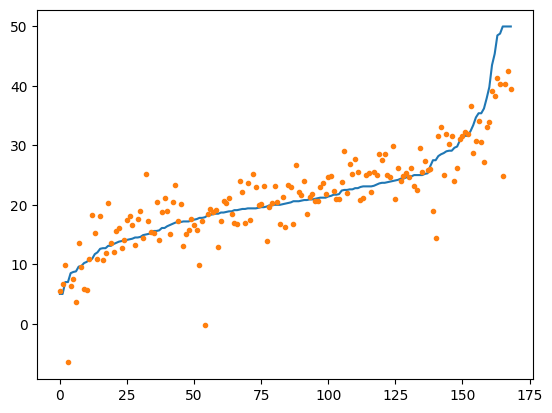

In [11]:
idx = np.argsort(y2)
y2=y2[idx]
X2=X2[idx,:]
y2e=lr.predict(X2)
plt.plot(y2)
plt.plot(y2e, '.')

In [12]:
sc = StandardScaler().fit(X1)
X1n = sc.transform(X1)
X2n = sc.transform(X2)

In [13]:
lr = LinearRegression().fit(X1n, y1)
print(lr.score(X1n, y1))
print(lr.score(X2n, y2))

0.7389831456966496
0.7262099239984429


In [14]:
np.std(X1, axis=0)

array([7.69053682e+00, 2.29972658e+01, 6.96652538e+00, 2.66831420e-01,
       1.17812221e-01, 7.21200221e-01, 2.79274664e+01, 2.14539646e+00,
       8.63977863e+00, 1.65882212e+02, 2.24152928e+00, 8.87188876e+01,
       7.18421693e+00])

1.0
0.7389831456966496
0.7262099239984429


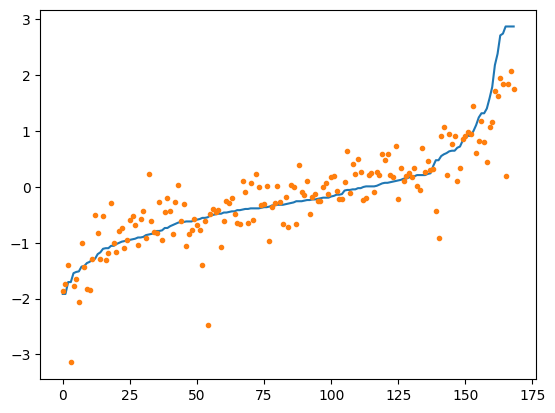

In [15]:
m1 = np.mean(y1)
s1 = np.std(y1)
y1 = (y1-m1)/s1
y2 = (y2-m1)/s1
print(np.std(y1))
np.mean(y1)
np.mean(y2)
np.std(y2)
lr = LinearRegression().fit(X1n, y1)
print(lr.score(X1n, y1))
print(lr.score(X2n, y2))
plt.plot(y2)
y2e = lr.predict(X2n)
plt.plot(y2e, '.')

In [16]:
pf = PolynomialFeatures(degree=3, include_bias=False).fit(X1n,y1)

In [17]:
X1p = pf.transform(X1n)
X2p = pf.transform(X2n)
print(X1p.shape)

(337, 559)


In [18]:
lr = LinearRegression().fit(X1p, y1)

In [19]:
lr.score(X1p, y1)
lr.score(X2p, y2)

-43.78861017295498

---

In [20]:
fn = './data/imdbFull.p'
D = pickle.load(open(fn, 'rb'))
D.keys()

dict_keys(['data', 'target', 'DESCR'])

In [60]:
doclist = D['data']
doclist = np.array(doclist)
y = D['target']
print(D.DESCR)

This dataset contains movie reviews along with their associated binary sentiment polarity labels. It is intended to serve as a benchmark for sentiment classification. This document outlines how the dataset was gathered, and how to use the files provided.
For more details see: http://ai.stanford.edu/~amaas/data/sentiment/


In [ ]:
cv = CountVectorizer().fit(doclist[:3])
voc = cv.vocabulary_
v = list(voc.keys())
print(len(v))

221


In [70]:
X = cv.transform(doclist[:3])
print(X.shape)
print(X)

(3, 221)
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 274 stored elements and shape (3, 221)>
  Coords	Values
  (0, 2)	1
  (0, 3)	1
  (0, 9)	1
  (0, 12)	2
  (0, 13)	1
  (0, 14)	1
  (0, 19)	1
  (0, 23)	2
  (0, 25)	2
  (0, 26)	1
  (0, 27)	1
  (0, 29)	1
  (0, 30)	4
  (0, 31)	2
  (0, 35)	1
  (0, 38)	1
  (0, 39)	1
  (0, 43)	1
  (0, 44)	1
  (0, 46)	1
  (0, 48)	1
  (0, 49)	1
  (0, 51)	1
  (0, 53)	1
  (0, 54)	1
  :	:
  (2, 132)	2
  (2, 133)	2
  (2, 134)	1
  (2, 136)	1
  (2, 138)	1
  (2, 139)	2
  (2, 143)	1
  (2, 148)	2
  (2, 151)	1
  (2, 153)	1
  (2, 157)	1
  (2, 166)	1
  (2, 174)	1
  (2, 179)	2
  (2, 180)	4
  (2, 181)	1
  (2, 187)	2
  (2, 190)	3
  (2, 195)	1
  (2, 196)	1
  (2, 200)	1
  (2, 201)	1
  (2, 202)	3
  (2, 203)	1
  (2, 205)	1


In [71]:
X.toarray()

array([[ 0,  0,  1,  1,  0,  0,  0,  0,  0,  1,  0,  0,  2,  1,  1,  0,
         0,  0,  0,  1,  0,  0,  0,  2,  0,  2,  1,  1,  0,  1,  4,  2,
         0,  0,  0,  1,  0,  0,  1,  1,  0,  0,  0,  1,  1,  0,  1,  0,
         1,  1,  0,  1,  0,  1,  1,  0,  0,  1,  0,  0,  0,  1,  0,  1,
         0,  0,  0,  0,  1,  0,  2,  0,  2,  1,  0,  1,  1,  1,  0,  1,
         1,  0,  0,  0,  0,  1,  0,  1,  0,  0,  0,  1,  1,  0,  0,  1,
         0,  0,  3,  0,  0,  4,  5,  0,  1,  0,  1,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  1,  0,  0,  1,  0,  1,  1,  1,  0,  0,  1,
         1,  2,  0,  0,  1,  4,  0,  0,  0,  0,  0,  0,  1,  0,  0,  0,
         1,  0,  1,  0,  0,  1,  0,  0,  0,  0,  1,  1,  1,  0,  0,  0,
         0,  1,  0,  1,  0,  0,  0,  0,  1,  1,  0,  0,  0,  2,  0,  0,
         2,  1,  2,  1,  3,  2,  0,  0,  1,  0,  2,  0,  1,  0,  4,  0,
         0,  3,  1,  0,  0,  0,  0,  2,  0,  0,  0,  0,  0,  3,  1,  1,
         0,  1,  1,  0,  0,  0,  1,  1,  0,  2,  2,  0,  1],
   

In [80]:
vs = cv.get_feature_names_out()
vs

array(['10', '747', 'actions', 'actors', 'advantage', 'airline',
       'airliner', 'airplane', 'all', 'almost', 'also', 'an', 'and',
       'anything', 'are', 'around', 'as', 'at', 'bad', 'be', 'because',
       'been', 'before', 'being', 'belushi', 'better', 'beyond',
       'bizarre', 'boeing', 'boys', 'br', 'but', 'by', 'can', 'cannot',
       'captures', 'chance', 'choice', 'civility', 'classmates',
       'clichés', 'coloring', 'colors', 'commit', 'common', 'count',
       'coupled', 'cry', 'day', 'decided', 'decision', 'define',
       'describe', 'destruction', 'did', 'didn', 'differently', 'do',
       'done', 'doubt', 'early', 'elephant', 'ends', 'even', 'every',
       'everyone', 'executive', 'explain', 'explaining', 'fact', 'far',
       'fictional', 'film', 'filmmaker', 'first', 'flawed', 'for', 'from',
       'get', 'gets', 'given', 'going', 'good', 'grip', 'guys', 'had',
       'has', 'have', 'he', 'here', 'his', 'honest', 'honesty',
       'horrible', 'how', 'humans', 

In [85]:
X[0:].toarray()

array([[ 0,  0,  1,  1,  0,  0,  0,  0,  0,  1,  0,  0,  2,  1,  1,  0,
         0,  0,  0,  1,  0,  0,  0,  2,  0,  2,  1,  1,  0,  1,  4,  2,
         0,  0,  0,  1,  0,  0,  1,  1,  0,  0,  0,  1,  1,  0,  1,  0,
         1,  1,  0,  1,  0,  1,  1,  0,  0,  1,  0,  0,  0,  1,  0,  1,
         0,  0,  0,  0,  1,  0,  2,  0,  2,  1,  0,  1,  1,  1,  0,  1,
         1,  0,  0,  0,  0,  1,  0,  1,  0,  0,  0,  1,  1,  0,  0,  1,
         0,  0,  3,  0,  0,  4,  5,  0,  1,  0,  1,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  1,  0,  0,  1,  0,  1,  1,  1,  0,  0,  1,
         1,  2,  0,  0,  1,  4,  0,  0,  0,  0,  0,  0,  1,  0,  0,  0,
         1,  0,  1,  0,  0,  1,  0,  0,  0,  0,  1,  1,  1,  0,  0,  0,
         0,  1,  0,  1,  0,  0,  0,  0,  1,  1,  0,  0,  0,  2,  0,  0,
         2,  1,  2,  1,  3,  2,  0,  0,  1,  0,  2,  0,  1,  0,  4,  0,
         0,  3,  1,  0,  0,  0,  0,  2,  0,  0,  0,  0,  0,  3,  1,  1,
         0,  1,  1,  0,  0,  0,  1,  1,  0,  2,  2,  0,  1],
   